In [23]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore', category=UserWarning)

os.makedirs('../../output/tables', exist_ok=True)
os.makedirs('../../output/figs', exist_ok=True)

In [24]:
plt.rcParams.update({
    'font.family'      : 'serif',
    'font.size'        : 9,
    'axes.titlesize'   : 10,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 9,
    'xtick.labelsize'  : 8,
    'ytick.labelsize'  : 8,
    'legend.fontsize'  : 8,
    'figure.dpi'       : 150, # High resolution for paper quality
})

Load Data

In [25]:
df = pd.read_csv('../../output/processed_data/05_filtered.csv')
print(df.columns.tolist())

['symbol', 'date', 'open', 'high', 'low', 'close', 'volume', 'base_symbol', 'sector', 'suffix_cat', 'aspi_open', 'aspi_high', 'aspi_low', 'aspi_close', 'R_i', 'R_m', 'day', 'alpha', 'beta', 'r_squared', 'dw_stat', 'jb_pvalue', 'n_obs', 'AR']


Calculate AR and daily spread

In [26]:
# AR was computed and sanity-checked in NB05.
# It is loaded directly from 05_filtered.csv — no need to recompute here.
assert 'AR' in df.columns, \
    "AR column missing from 05_filtered.csv — re-run NB05 first."
print(f'✓ AR loaded from 05_filtered.csv  ({df["AR"].notna().sum()} non-null values)')

# Spread is not in the saved CSV — compute it fresh here (high - low)
df['Spread'] = df['high'] - df['low']

✓ AR loaded from 05_filtered.csv  (69390 non-null values)


Wilcoxon Signed Rank test

In [27]:
full_window = df[(df['day'] >= -5) & (df['day'] <= 30)]
stock_cars = full_window.groupby(['symbol', 'sector'])['AR'].sum().reset_index()
stock_cars.rename(columns={'AR':'CAR'}, inplace = True)
stock_cars['CAR(%)'] = stock_cars['CAR'] * 100

wilcoxon_results = []
sectors = stock_cars['sector'].unique()

for sector in sectors:
    sector_data = stock_cars[stock_cars['sector'] == sector]['CAR(%)']
    n_stocks = len(sector_data)

    if n_stocks > 1:
        try:
            w_stat, p_val_w  = stats.wilcoxon(sector_data, alternative='two-sided')
        except ValueError:
            w_stat, p_val_w = np.nan, np.nan
    else:
        w_stat, p_val_w = np.nan, np.nan
    
    wilcoxon_results.append({
        'Sector': sector,
        'N': n_stocks,
        'Median CAR(%)': sector_data.median(),
        'W-statistic': w_stat,
        'p-value': p_val_w,
        'Significant': p_val_w < 0.05 if pd.notna(p_val_w) else False
    })

wilcoxon_df = pd.DataFrame(wilcoxon_results).sort_values(by='Median CAR(%)', ascending=False)

wilcoxon_df.to_csv('../../output/tables/wilcoxon_results.csv', index=False)
formatted_df = wilcoxon_df.copy()
formatted_df['Median CAR(%)'] = formatted_df['Median CAR(%)'].apply(lambda x: f"{x:.2f}%")
formatted_df['p-value'] = formatted_df['p-value'].apply(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")
formatted_df.to_csv('../../output/tables/wilcoxon_results_formatted.csv', index=False)  


Volatility and Liquidity Analysis

In [28]:
print("Running pre Vs. Post Disaster Volatility & Liquidity Analysis")

pre_window = df[(df['day'] >= -30) & (df['day'] <= -6)]
post_window = df[(df['day'] >= 0) & (df['day'] <= 24)]

pre_market_spread = pre_window.groupby('day')['Spread'].mean().reset_index()
post_market_spread = post_window.groupby('day')['Spread'].mean().reset_index()

pre_market_vol = pre_window.groupby('day')['volume'].mean().reset_index()
post_market_vol = post_window.groupby('day')['volume'].mean().reset_index()


t_stat_spread, p_val_spread = stats.ttest_ind(
    pre_market_spread['Spread'], post_market_spread['Spread'], equal_var=False
)
t_stat_vol, p_val_vol = stats.ttest_ind(
    pre_market_vol['volume'], post_market_vol['volume'], equal_var=False
)

volatility_liquidity_results = pd.DataFrame({
    'Metric': ['Volatility (Mean Spread)', 'Liquidity (Total Volume)'],
    'Pre-Event Mean': [pre_market_spread['Spread'].mean(), pre_market_vol['volume'].mean()],
    'Post-Event Mean': [post_market_spread['Spread'].mean(), post_market_vol['volume'].mean()],
    'T-Statistic': [t_stat_spread, t_stat_vol],
    'P-Value': [p_val_spread, p_val_vol],
    'Significance_at_5%': [p_val_spread < 0.05, p_val_vol < 0.05]
})

volatility_liquidity_results.to_csv('../../output/tables/volatility_liquidity_summary.csv', index=False)


Running pre Vs. Post Disaster Volatility & Liquidity Analysis


ROBUSTNESS CHECKS & ANTICIPATION ANALYSIS

In [29]:
# =============================================================================
# ► NEW: Robustness Checks & Anticipation Analysis          (added)
# =============================================================================
print("\nRunning Robustness Checks and Anticipation Tests...")

# ── 1. Anticipation Test: CAR(−5, −1) ────────────────────────────────────────
anticipation_window = df[(df['day'] >= -5) & (df['day'] <= -1)]
anticipation_cars   = anticipation_window.groupby('symbol')['AR'].sum() * 100

mean_anti    = anticipation_cars.mean()
t_anti, p_anti = stats.ttest_1samp(anticipation_cars, 0)

print(f"\n[Anticipation Results  CAR(-5,-1)]")
print(f"  Mean : {mean_anti:.2f}%")
print(f"  t    : {t_anti:.4f}")
print(f"  p    : {p_anti:.4f}")

# ── 2. Sector-level anticipation t-tests ─────────────────────────────────────
# (feeds Section 3.X "Pre-Event Anticipation" in the paper)
anticipation_sector_cars = (
    anticipation_window
    .groupby(['symbol', 'sector'])['AR']
    .sum()
    .reset_index()
)
anticipation_sector_cars['CAR(%)'] = anticipation_sector_cars['AR'] * 100

anticipation_sector_results = []
for sector in anticipation_sector_cars['sector'].unique():
    s_data  = anticipation_sector_cars[
        anticipation_sector_cars['sector'] == sector]['CAR(%)']
    n = len(s_data)
    if n > 1:
        t_s, p_s = stats.ttest_1samp(s_data, 0)
    else:
        t_s, p_s = np.nan, np.nan
    anticipation_sector_results.append({
        'Sector'    : sector,
        'N'         : n,
        'Mean CAR(%)': s_data.mean(),
        'T-Stat'    : t_s,
        'P-Value'   : p_s,
    })

anticipation_sector_df = pd.DataFrame(anticipation_sector_results).sort_values(
    'Mean CAR(%)')
anticipation_sector_df.to_csv(
    '../../output/tables/anticipation_sector_results.csv', index=False)

print("\n[Sector-level anticipation results saved]")
print(anticipation_sector_df[['Sector','N','Mean CAR(%)','P-Value']].to_string(
    index=False))

# ── 3. Market-Adjusted Model robustness check (α=0, β=1) ─────────────────────
# AR_robust = stock_return − market_return  (no OLS estimation)
df['AR_robust'] = df['R_i'] - df['R_m']

robust_window = df[(df['day'] >= -5) & (df['day'] <= 30)]
robust_cars   = robust_window.groupby('symbol')['AR_robust'].sum() * 100

mean_rob       = robust_cars.mean()
t_rob, p_rob   = stats.ttest_1samp(robust_cars, 0)

print(f"\n[Robustness Results: Market-Adjusted Model  CAR(-5,+30)]")
print(f"  Mean CAR : {mean_rob:.2f}%")
print(f"  t        : {t_rob:.4f}")
print(f"  p        : {p_rob:.4f}")

# ── 4. Save combined robustness summary ──────────────────────────────────────
robustness_summary = pd.DataFrame({
    'Test'    : ['Anticipation (-5,-1)', 'Market-Adjusted Robustness (-5,+30)'],
    'Mean_CAR': [mean_anti, mean_rob],
    'T_Stat'  : [t_anti,    t_rob],
    'P_Val'   : [p_anti,    p_rob],
})
robustness_summary.to_csv(
    '../../output/tables/robustness_tests.csv', index=False)
print("\n✓ Robustness summary saved to output/tables/robustness_tests.csv")


Running Robustness Checks and Anticipation Tests...

[Anticipation Results  CAR(-5,-1)]
  Mean : -1.01%
  t    : -2.9549
  p    : 0.0034

[Sector-level anticipation results saved]
                    Sector  N  Mean CAR(%)  P-Value
            Transportation  3    -6.410697 0.019722
                    Energy  3    -6.189744 0.200542
                 Retailing 14    -4.100072 0.219321
Telecommunication Services  2    -3.033591 0.003743
                 Materials 22    -2.510958 0.089735
         Consumer Durables  8    -2.061963 0.302235
                 Utilities  9    -1.825882 0.121755
       Software & Services  1    -1.499230      NaN
    Diversified Financials 39    -1.448643 0.017165
                 Insurance 13    -1.169676 0.206661
               Real Estate 17    -1.093517 0.422547
             Capital Goods 30    -0.834568 0.246625
                     Banks 17    -0.426369 0.651261
           Food & Beverage 45    -0.331047 0.623323
      Healthcare Equipment  9    -0.110

Publication Quality Plots

C:\Users\User\AppData\Local\Temp\ipykernel_6204\567858985.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='CAR(%)', y='sector', data=stock_cars, order=order, palette='coolwarm')


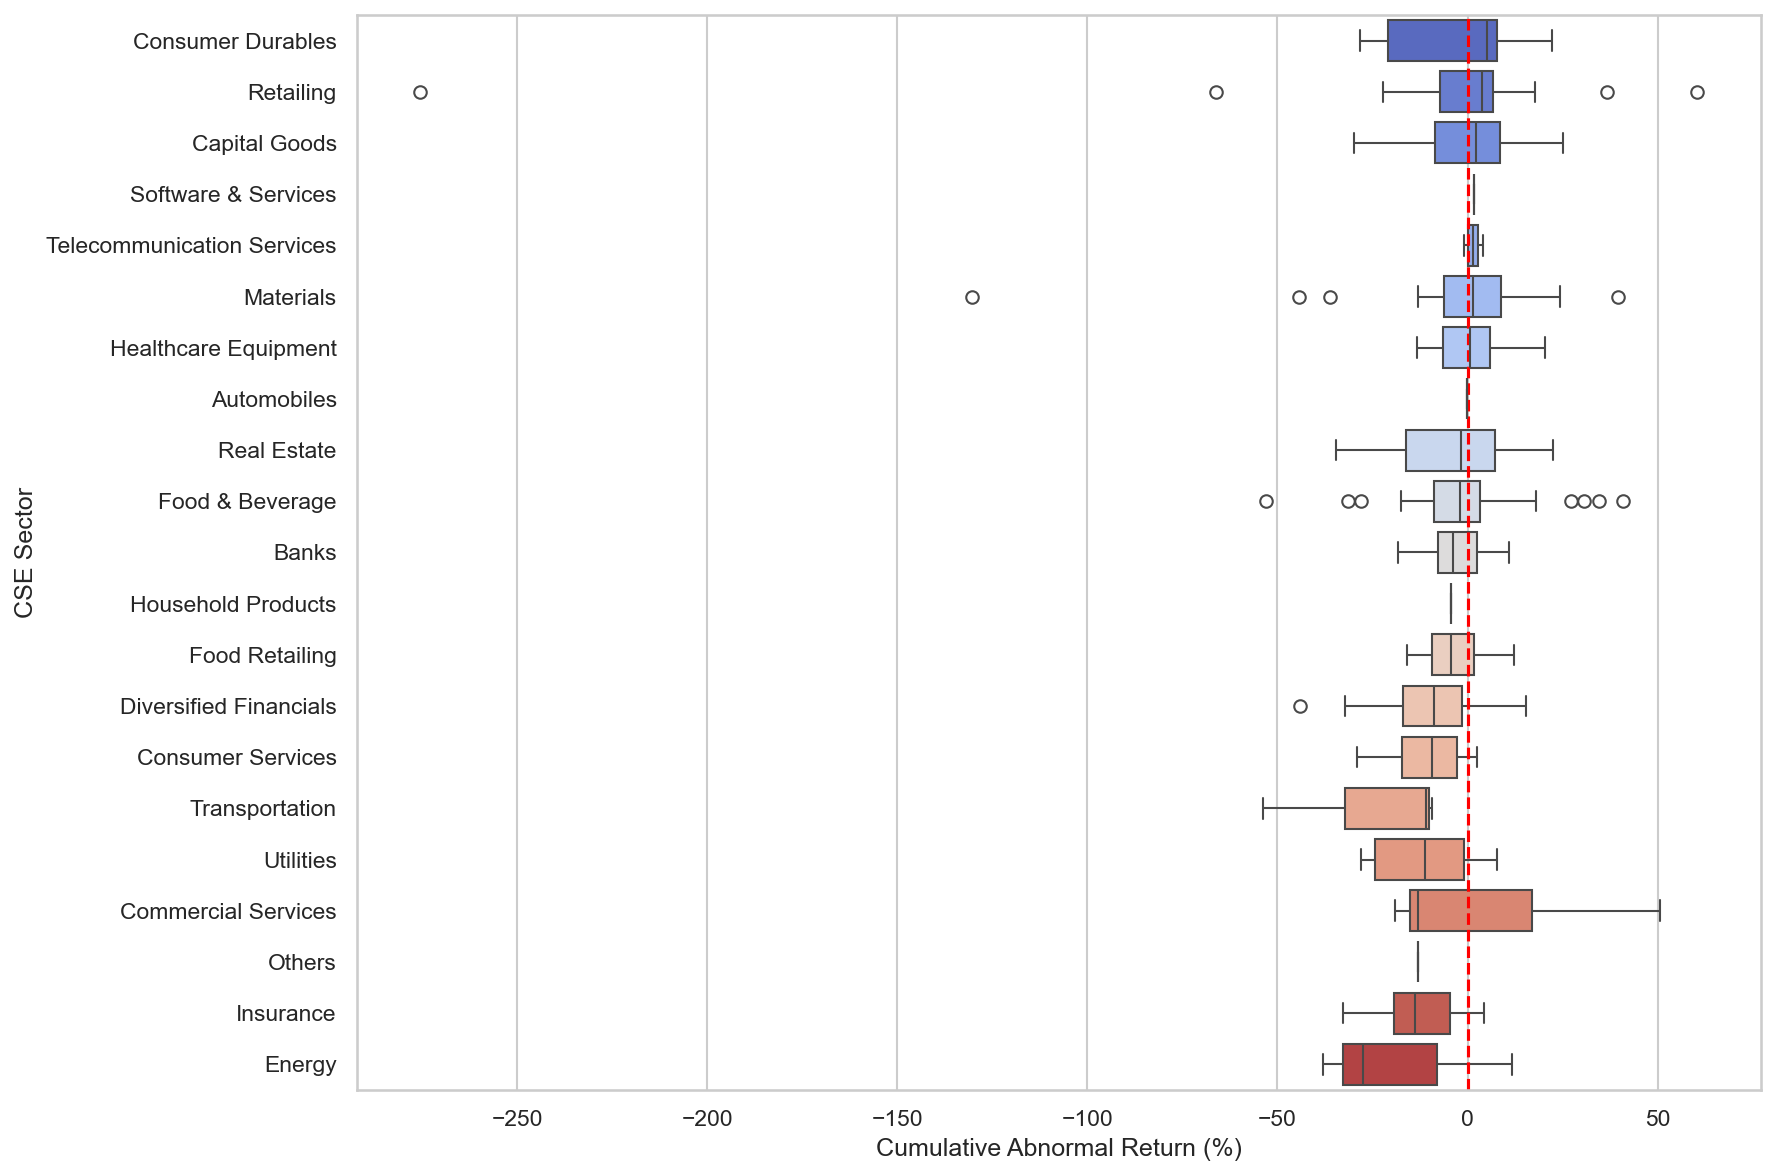

In [30]:
sns.set_theme(style="whitegrid")

#1. Sector Car Plot[-5, +30]
plt.figure(figsize=(12, 8))

order = stock_cars.groupby('sector')['CAR(%)'].median().sort_values(ascending=False).index
sns.boxplot(x='CAR(%)', y='sector', data=stock_cars, order=order, palette='coolwarm')

plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel('Cumulative Abnormal Return (%)', fontsize=12)
plt.ylabel('CSE Sector', fontsize=12)
plt.tight_layout()
plt.savefig('../../output/figs/sector_car_boxplot.pdf', dpi=300)
plt.show()
plt.close()

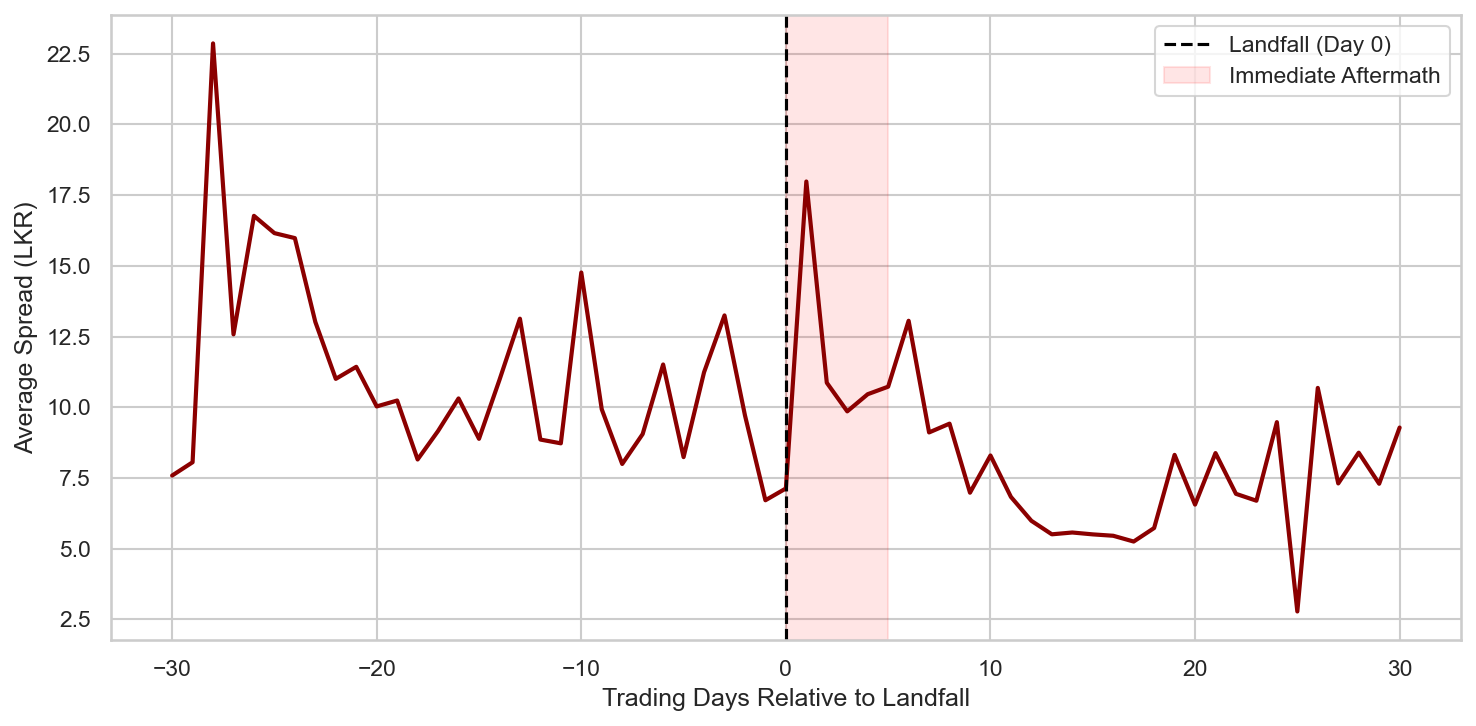

In [31]:
#2. Market Volatility over Time

daily_spread = df[(df['day'] >= -30) & (df['day'] <= 30)].groupby('day')['Spread'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(x='day', y='Spread', data=daily_spread, color='darkred', linewidth=2)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5, label='Landfall (Day 0)')
plt.axvspan(0, 5, color='red', alpha=0.1, label='Immediate Aftermath')
plt.xlabel('Trading Days Relative to Landfall', fontsize=12)
plt.ylabel('Average Spread (LKR)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('../../output/figs/market_volatility_lineplot.pdf', dpi=300)
plt.show()
plt.close()

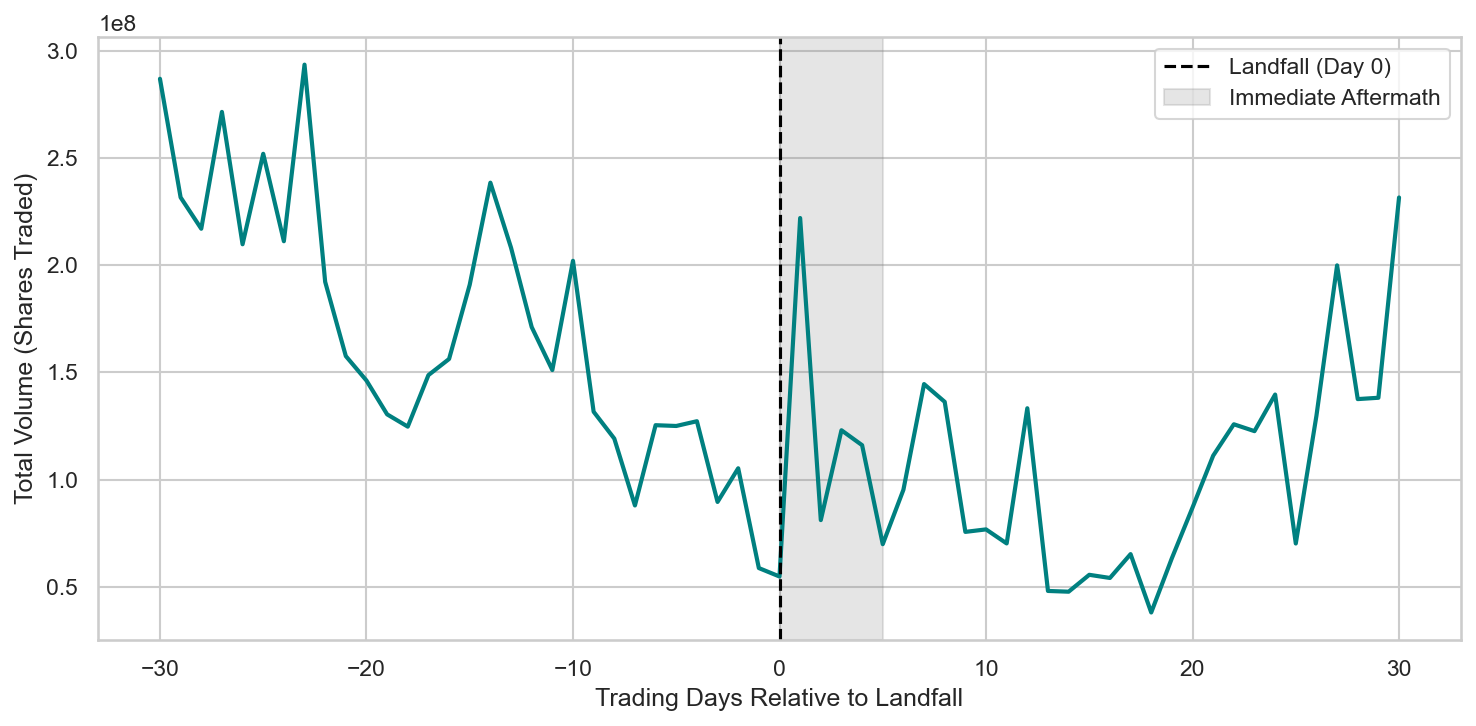

In [32]:
#3. Market Liquidity over Time

daily_vol = df[(df['day'] >= -30) & (df['day'] <= 30)].groupby('day')['volume'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(x='day', y='volume', data=daily_vol, color='teal', linewidth=2)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5, label='Landfall (Day 0)')
plt.axvspan(0, 5, color='gray', alpha=0.2, label='Immediate Aftermath')
plt.xlabel('Trading Days Relative to Landfall', fontsize=12)
plt.ylabel('Total Volume (Shares Traded)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('../../output/figs/market_liquidity_lineplot.pdf', dpi=300)
plt.show()
plt.close()